## IMPORT LIBRARIES

In [1]:
import pandas as pd
from wordcloud import WordCloud
import re
from nltk.corpus import stopwords
import matplotlib.pyplot as plt

In [2]:
# Loading Data ...
df = pd.read_csv("train_data.csv",low_memory=False)

In [3]:
# preprocessing
df_ow = df[["overall","reviewText"]].copy()
df_ow["reviewText"] = df_ow["reviewText"].str.lower()
df_ow["reviewText"] = df_ow["reviewText"].apply(lambda x : re.sub(r"[^\w\s]", "",x))
df_ow["reviewText"] = df_ow["reviewText"].apply(lambda x : re.sub(r"\d+", "",x))
stop_words = set(stopwords.words("english"))
df_ow["reviewText"] = df_ow["reviewText"].apply(lambda x : " ".join(word for word in x.split() if word not in stop_words))

In [4]:
# Dividing
positive = " ".join(df_ow[df_ow["overall"] >= 4]["reviewText"])
neutral = " ".join(df_ow[df_ow["overall"] == 3]["reviewText"])
negative = " ".join(df_ow[df_ow["overall"] <= 2]["reviewText"])

## USING WORD CLOUD

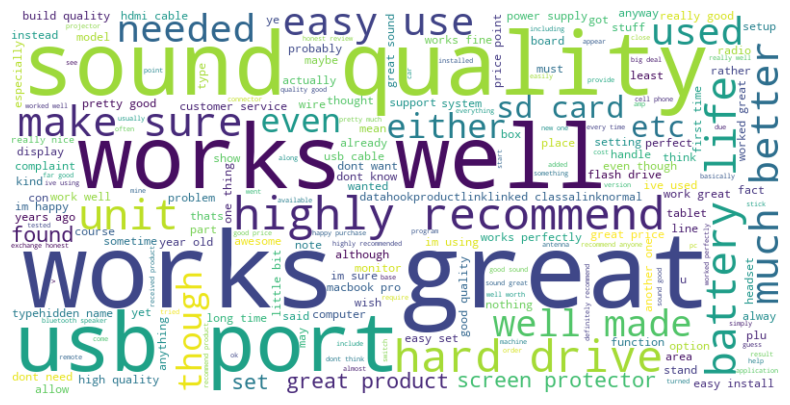

In [5]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(positive)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.savefig("positive_words.png", dpi=300, bbox_inches="tight")
plt.show()

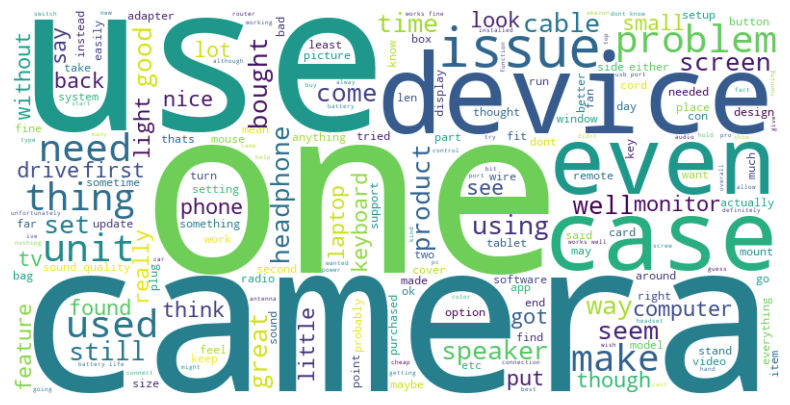

In [6]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(neutral)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.savefig("normal_words.png", dpi=300, bbox_inches="tight")
plt.show()

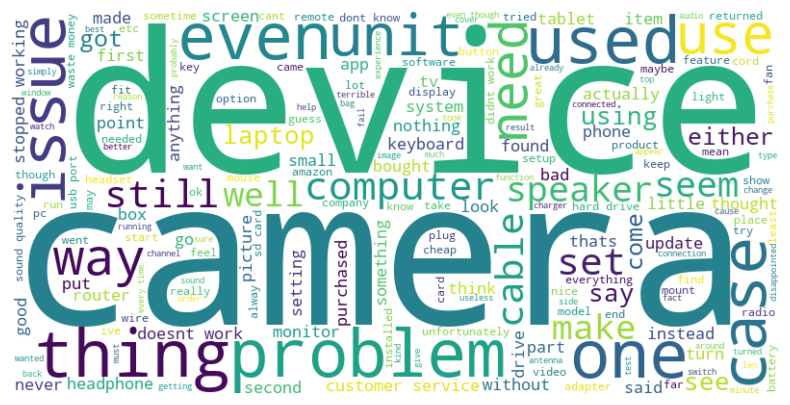

In [7]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(negative)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.savefig("negative_words.png", dpi=300, bbox_inches="tight")
plt.show()

## CONCLUSION


### Three Word Clouds were created for positive, neutral, and negative reviews after removing stop words. The positive reviews contain words such as “quality”, “great”, “recommend”, and “works well”, which show customer satisfaction. The negative reviews include words like “problem” and “issue”, indicating customer complaints. Some words, such as “camera”, “device”, “case”, and “unit”, appear in both positive and negative reviews because users are discussing the same products from different perspectives.